### Elastic Properties Log Processing of Well GT-01 (Delft Geothermal)
#### Exercise 3 - Geomechanics and Structural Geology (March 2026)

- Pablo Oliver - 6483186
- Nanda Najih Habibil Afif - 6424732
- Lennard Stoeck - 6566545


#### *Task:*

Based on the contrast in mechanical properties between different layers, one can predict with what contrast, fracturing in alternating layers occurs in a tensile or compressive regime. This is explained in the manuscript of Boersma et al. (see pdf on Brightspace).

Based on log data of well K12-17 (in which p-wave velocity, s-wave velocity and density is measured, these authors have calculated the mechanical properties (Young’s modulus and Poisson’s ratio) for each layer (Fig. 9 of that pdf). From the contrast between these properties (and the numerical modelling exercise, illustrated in e.g. figures 3 and 7 of that pdf, they have calculated which of those layers is expected to fracture in tension or in compression. Please read this paper and try to reproduce the mechanical stratigraphy (figure 9) for the geothermal well of the Delft Geothermal doublet. The reservoir in the Delft sandstone formation consists of an alternation of shales and sand horizons. Produce a mechanical stratigraphy plot for these layers.

Produce this figure and discuss in 5-6 sentences the importance of your findings.

#### *Solution:*

In [279]:
!pip install lasio

In [280]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lasio

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

#### **1. Loading LAS Files**

We have two LAS files:
- TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_XMAC_HDIL_MAIN, this contains DTC QI (P-wave), DTSQI (S-wave)
- TU_DELFT_GT01_8.5in_WL_run31_10Sep2023_ZDL_CN_MAIN, this containsZDEN (density).

In [281]:
# Load LAS files
las_acoustic_file = r'D:\TUDelftLectures\Q3\Geomech\Geomechanics-Q3\# Exercise GMSG 3\TU_DELFT_GT01_8.5in_WL_run11_09Sep2023_XMAC_HDIL_MAIN.las'
las_density_file = r'D:\TUDelftLectures\Q3\Geomech\Geomechanics-Q3\# Exercise GMSG 3\TU_DELFT_GT01_8.5in_WL_run31_10Sep2023_ZDL_CN_MAIN.las'

las_acoustic = lasio.read(las_acoustic_file)
las_density = lasio.read(las_density_file)

print(f"Depth range: {las_acoustic.well.STRT.value:.0f}-{las_acoustic.well.STOP.value:.0f} m")

Depth range: 2507-2934 m


In [282]:
# Convert to DataFrames
df_acoustic = las_acoustic.df().reset_index()
df_density = las_density.df().reset_index()

#### **2. Extracting Required Curves:**

Extracting required curves:
- DEPT: Depth (m)
- DTCQI: P-wave slowness (μs/ft)
- DTSQI: S-wave slowness (μs/ft)
- ZDEN/ZDNC: Density (g/cm³)

In [283]:
# Merging acoustic and density data
df_merged = pd.merge(df_acoustic[['DEPT', 'DTCQI', 'DTSQI', 'GR']], 
                     df_density[['DEPT', 'ZDEN', 'ZDNC', 'CN']], 
                     on='DEPT', how='inner')

df_merged = df_merged.replace(-999.25, np.nan)
df_merged['DENSITY'] = df_merged['ZDNC'].fillna(df_merged['ZDEN'])

df_clean = df_merged[['DEPT', 'DTCQI', 'DTSQI', 'DENSITY', 'GR', 'CN']].dropna()

print(f"Clean data points: {len(df_clean)} ({df_clean['DEPT'].min():.0f}-{df_clean['DEPT'].max():.0f} m)")
df_clean.describe()

Clean data points: 4593 (2553-2907 m)


,DEPT,DTCQI,DTSQI,DENSITY,GR,CN
count,4593.000000,4593.000000,4593.000000,4593.000000,4593.000000,4593.000000
mean,2731.879497,72.052988,128.583488,2.313434,45.583562,18.272810
std,101.117195,5.820779,9.772790,0.766955,35.423905,5.556752
min,2552.776200,58.901500,100.399700,-7.036000,7.796300,5.400100
25%,2644.444800,66.970800,122.562800,2.310400,14.590100,15.285200
50%,2731.922400,73.078000,128.624400,2.369200,30.416500,17.726800
75%,2819.400000,76.701900,133.905500,2.568400,78.296000,19.848400
max,2906.877600,88.580600,183.323100,4.943400,138.255200,59.329800


## 3. Calculate Velocities from Slowness

Convert slowness (μs/ft) to velocity (m/s):

$$ V_p = \frac{304.8}{\text{DTCQI}} \quad [\text{m/s}] $$

$$ V_s = \frac{304.8}{\text{DTSQI}} \quad [\text{m/s}] $$

where 304.8 converts ft to m (1 ft = 0.3048 m, and 10⁶/0.3048 = 304.8 for μs conversion)

In [284]:
# Convert slowness to velocity: V = 304.8 / DT
df_clean['Vp'] = 304.8 / df_clean['DTCQI']
df_clean['Vs'] = 304.8 / df_clean['DTSQI']
df_clean['rho'] = df_clean['DENSITY'] * 1000

#### **4. Calculating Dynamic Elastic Properties**

Based on paper Boersma, Q. D., Douma, L. A. N. R., Bertotti, G., & Barnhoorn, A. (2020). *Mechanical controls on horizontal stresses and fracture behaviour in layered rocks: A numerical sensitivity analysis.* Journal of Structural Geology, 130, 103907. https://doi.org/10.1016/j.jsg.2019.103907, particulary at page 9:

- Bulk Modulus ($K_{dyn}$)
$$ K_{dyn} = \rho \left( V_p^2 - \frac{4}{3} V_s^2 \right) \quad [\text{Pa}] $$

- Shear Modulus ($μ_{dyn}$ or $G$)
$$ \mu_{dyn} = \rho V_s^2 \quad [\text{Pa}] $$

- Young's Modulus ($E_{dyn}$)
$$ E_{dyn} = \frac{9 K_{dyn} \mu_{dyn}}{3 K_{dyn} + \mu_{dyn}} \quad [\text{Pa}] $$

- Poisson's Ratio ($ν_{dyn}$)
$$ \nu_{dyn} = \frac{3K_{dyn} - 2\mu_{dyn}}{2(3K_{dyn} + \mu_{dyn})}\quad [\text{Dimensionless}] $$

In [285]:
# Calculating elastic properties
df_clean['K_dyn'] = df_clean['rho'] * (df_clean['Vp']**2 - (4/3) * df_clean['Vs']**2)
df_clean['mu_dyn'] = df_clean['rho'] * df_clean['Vs']**2
df_clean['E_dyn'] = (9 * df_clean['K_dyn'] * df_clean['mu_dyn']) / (3 * df_clean['K_dyn'] + df_clean['mu_dyn'])
df_clean['nu_dyn'] = (3 * df_clean['K_dyn'] - 2 * df_clean['mu_dyn']) / (2 * (3 * df_clean['K_dyn'] + df_clean['mu_dyn']))

# Converting to GPa
df_clean['K_dyn_GPa'] = df_clean['K_dyn'] / 1e9
df_clean['mu_dyn_GPa'] = df_clean['mu_dyn'] / 1e9
df_clean['E_dyn_GPa'] = df_clean['E_dyn'] / 1e9

df_clean[['K_dyn_GPa', 'mu_dyn_GPa', 'E_dyn_GPa', 'nu_dyn']].describe()

,K_dyn_GPa,mu_dyn_GPa,E_dyn_GPa,nu_dyn
count,4593.000000,4593.000000,4593.000000,4593.000000
mean,0.000024,0.000013,0.000034,0.265868
std,0.000012,0.000005,0.000013,0.043290
min,-0.000117,-0.000042,-0.000113,0.004009
25%,0.000020,0.000012,0.000031,0.235481
50%,0.000023,0.000013,0.000033,0.259338
75%,0.000032,0.000015,0.000039,0.296708
max,0.000063,0.000037,0.000092,0.398678


In [286]:
# Elastic properties summary
df_clean[['Vp', 'Vs', 'E_dyn_GPa', 'nu_dyn']].describe()

,Vp,Vs,E_dyn_GPa,nu_dyn
count,4593.000000,4593.000000,4593.000000,4593.000000
mean,4.258614,2.383993,0.000034,0.265868
std,0.352714,0.179861,0.000013,0.043290
min,3.440934,1.662638,-0.000113,0.004009
25%,3.973826,2.276232,0.000031,0.235481
50%,4.170886,2.369690,0.000033,0.259338
75%,4.551237,2.486888,0.000039,0.296708
max,5.174741,3.035866,0.000092,0.398678


#### **5. Plotting in Multi-Panel Elastic Properties Log**

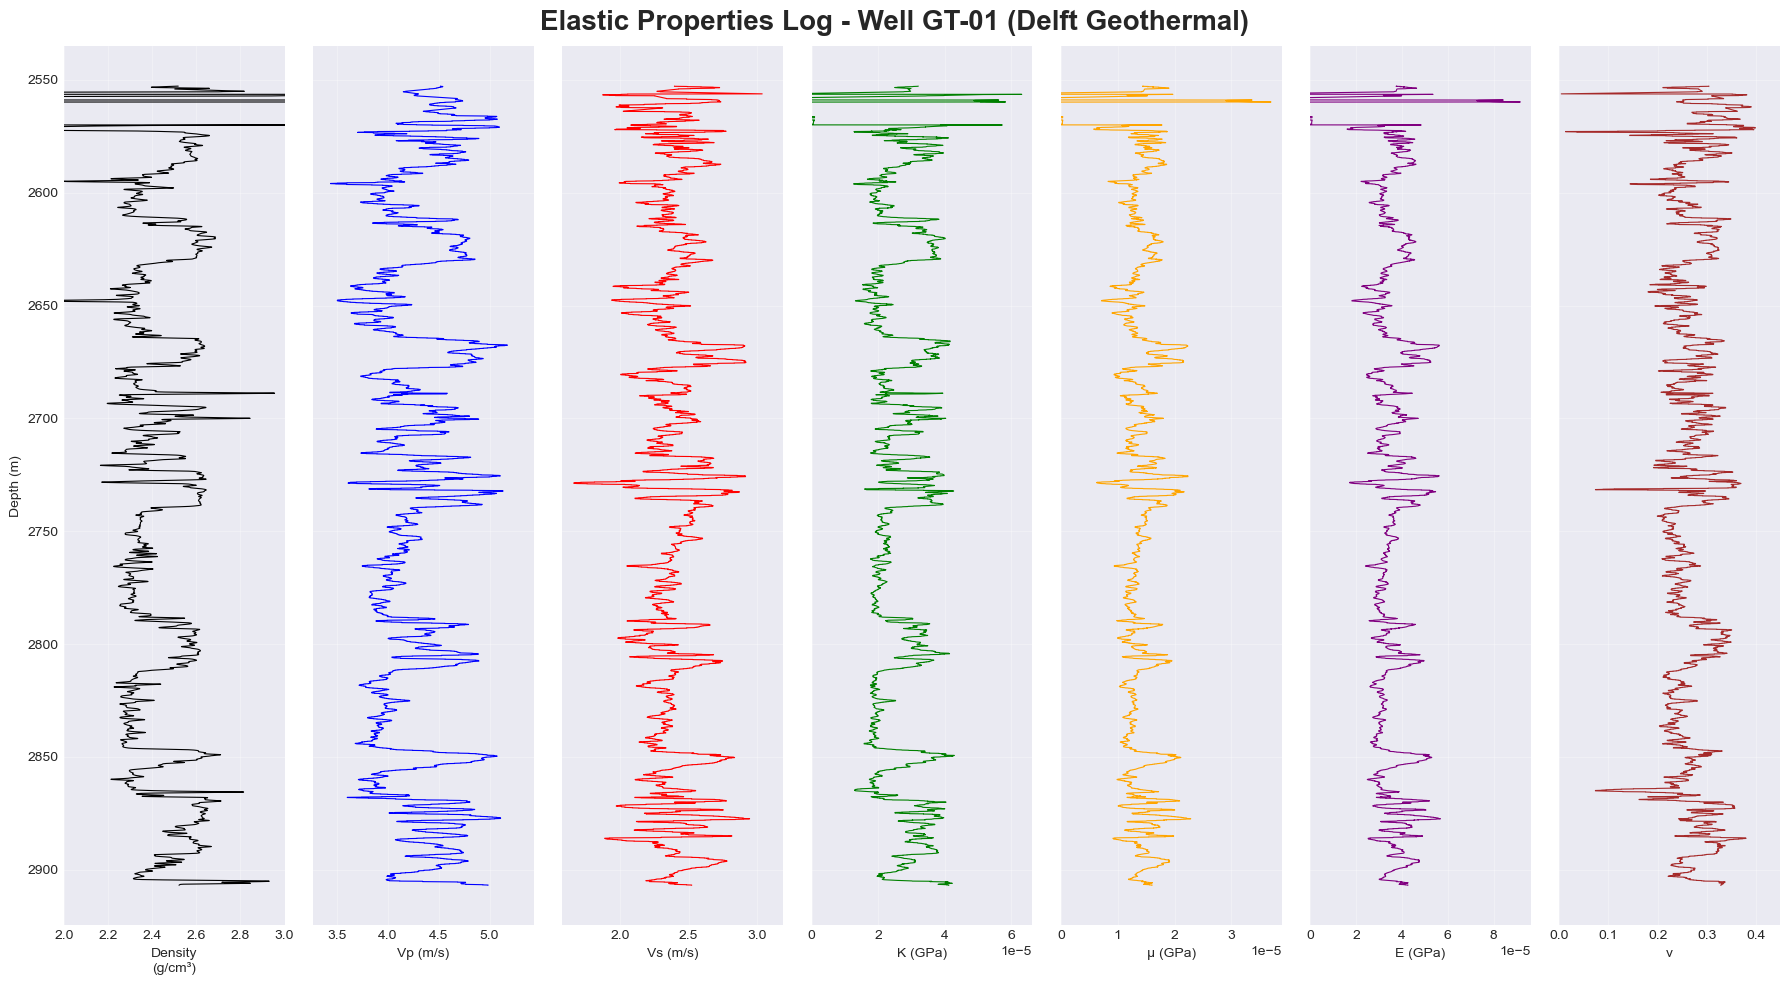

In [287]:
# Prepare data for plotting
df_plot = df_clean.replace([np.inf, -np.inf], np.nan).copy()

# Create 7-panel figure
fig, axes = plt.subplots(1, 7, figsize=(18, 10), sharey=True)
fig.suptitle('Elastic Properties Log - Well GT-01 (Delft Geothermal)', fontsize=20, fontweight='bold')

# (a) Density
axes[0].plot(df_plot['DENSITY'], df_plot['DEPT'], 'k-', linewidth=0.8)
axes[0].set_xlabel('Density\n(g/cm³)')
axes[0].set_ylabel('Depth (m)')
axes[0].set_xlim(2.0, 3.0)
axes[0].grid(alpha=0.3)
axes[0].invert_yaxis()

# (b) P-wave velocity
valid_vp = df_plot['Vp'].dropna()
axes[1].plot(df_plot['Vp'], df_plot['DEPT'], 'b-', linewidth=0.8)
axes[1].set_xlim(valid_vp.min() * 0.95, valid_vp.max() * 1.05)
axes[1].set_xlabel('Vp (m/s)')
axes[1].grid(alpha=0.3)

# (c) S-wave velocity
valid_vs = df_plot['Vs'].dropna()
axes[2].plot(df_plot['Vs'], df_plot['DEPT'], 'r-', linewidth=0.8)
axes[2].set_xlim(valid_vs.min() * 0.95, valid_vs.max() * 1.05)
axes[2].set_xlabel('Vs (m/s)')
axes[2].grid(alpha=0.3)

# (d) Bulk modulus
valid_k = df_plot['K_dyn_GPa'].dropna()
axes[3].plot(df_plot['K_dyn_GPa'], df_plot['DEPT'], 'g-', linewidth=0.8)
axes[3].set_xlim(0, valid_k.max() * 1.05)
axes[3].set_xlabel('K (GPa)')
axes[3].grid(alpha=0.3)

# (e) Shear modulus
valid_mu = df_plot['mu_dyn_GPa'].dropna()
axes[4].plot(df_plot['mu_dyn_GPa'], df_plot['DEPT'], 'orange', linewidth=0.8)
axes[4].set_xlim(0, valid_mu.max() * 1.05)
axes[4].set_xlabel('μ (GPa)')
axes[4].grid(alpha=0.3)

# (f) Young's modulus
valid_e = df_plot['E_dyn_GPa'].dropna()
axes[5].plot(df_plot['E_dyn_GPa'], df_plot['DEPT'], 'purple', linewidth=0.8)
axes[5].set_xlim(0, valid_e.max() * 1.05)
axes[5].set_xlabel('E (GPa)')
axes[5].grid(alpha=0.3)

# (g) Poisson's ratio
valid_nu = df_plot['nu_dyn'].dropna()
axes[6].plot(df_plot['nu_dyn'], df_plot['DEPT'], 'brown', linewidth=0.8)
axes[6].set_xlim(0, min(0.5, valid_nu.max() + 0.05))
axes[6].set_xlabel('ν')
axes[6].grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **6. Exporting Data to CSV (a source to create mechanical stratigraphy)**

In [288]:
# Exporting to CSV
export_cols = ['DEPT', 'DENSITY', 'Vp', 'Vs', 'K_dyn_GPa', 'mu_dyn_GPa', 'E_dyn_GPa', 'nu_dyn', 'GR', 'CN']
df_export = df_clean[export_cols].copy()
df_export.columns = ['Depth_m', 'Density_g_cm3', 'Vp_m_s', 'Vs_m_s', 
                     'Bulk_Modulus_GPa', 'Shear_Modulus_GPa', 'Youngs_Modulus_GPa', 
                     'Poissons_Ratio', 'Gamma_Ray_gAPI', 'Neutron_Porosity_pu']

output_file = r'D:\TUDelftLectures\Q3\Geomech\Geomechanics-Q3\# Exercise GMSG 3\GT01_Elastic_Properties.csv'
df_export.to_csv(output_file, index=False)
print(f"Exported {len(df_export)} records to CSV")

Exported 4593 records to CSV


#### **7. Mechanical Stratigraphy - Variable Layer Analysis**

In this step, we generate a mechanical stratigraphy model that identifies stratigraphy layers based on mechanical property contrasts. Some steps and consideration are explained as follow:

1. Calculating rate of change (gradient) in Young's modulus with depth. Changes indicate transition between different lithologies (e.g., shale to sandstone, as dominant lithologies mentioned in the task above).

2. Using the 95th percentile of the gradient distribution as a threshold (this formulation / idea is given by AI). Points exceeding this threshold will be marked as mechanical property changes, then defined as *layer boundaries*.

3. To improve visibility (avoiding too detail layers / too thin), we did merging for layers thinner than 2.5 m with adjacent layers using thickness-weighted averaging. This to ease further geomechanical analysis.

4. Calculating the average Young's modulus (E) and Poisson's ratio (ν) for each boundaries.

In [289]:
# Sorting data by depth (from shallow to deep)
df_layers = df_clean.sort_values('DEPT').reset_index(drop=True)

# Calculating gradient (rate of change) of Young's modulus
df_layers['E_gradient'] = df_layers['E_dyn_GPa'].diff().abs()

# Using 95th percentile as threshold for significant changes
threshold = df_layers['E_gradient'].quantile(0.95)

# Marking layer boundaries where gradient exceeds threshold
df_layers['is_boundary'] = (df_layers['E_gradient'] > threshold).astype(int)

# Creating initial layer numbers
df_layers['Layer'] = df_layers['is_boundary'].cumsum() + 1

# Calculating initial layer properties
layer_stats = df_layers.groupby('Layer').agg({
    'DEPT': ['min', 'max'],
    'E_dyn_GPa': 'mean',
    'nu_dyn': 'mean'
}).reset_index()

layer_stats.columns = ['Layer', 'Depth_min', 'Depth_max', 'E_avg', 'nu_avg']
layer_stats['Thickness'] = layer_stats['Depth_max'] - layer_stats['Depth_min']

# Merging layers thinner than 2.5m with adjacent layers
min_thickness = 2.5
merged = True
while merged:
    merged = False
    for i in range(len(layer_stats)):
        if layer_stats.loc[i, 'Thickness'] < min_thickness:
            # Merging with previous layer if exists, otherwise with next
            if i > 0:

                # Merging with previous layer
                prev_idx = i - 1
                layer_stats.loc[prev_idx, 'Depth_max'] = layer_stats.loc[i, 'Depth_max']
                layer_stats.loc[prev_idx, 'Thickness'] = layer_stats.loc[prev_idx, 'Depth_max'] - layer_stats.loc[prev_idx, 'Depth_min']

                # Weighted average of properties
                thick_prev = layer_stats.loc[prev_idx, 'Thickness'] - layer_stats.loc[i, 'Thickness']
                thick_curr = layer_stats.loc[i, 'Thickness']
                layer_stats.loc[prev_idx, 'E_avg'] = (layer_stats.loc[prev_idx, 'E_avg'] * thick_prev + layer_stats.loc[i, 'E_avg'] * thick_curr) / layer_stats.loc[prev_idx, 'Thickness']
                layer_stats.loc[prev_idx, 'nu_avg'] = (layer_stats.loc[prev_idx, 'nu_avg'] * thick_prev + layer_stats.loc[i, 'nu_avg'] * thick_curr) / layer_stats.loc[prev_idx, 'Thickness']
                layer_stats = layer_stats.drop(i).reset_index(drop=True)
                merged = True
                break
            elif i < len(layer_stats) - 1:

                # Merge with next layer
                next_idx = i + 1
                layer_stats.loc[i, 'Depth_max'] = layer_stats.loc[next_idx, 'Depth_max']
                layer_stats.loc[i, 'Thickness'] = layer_stats.loc[i, 'Depth_max'] - layer_stats.loc[i, 'Depth_min']

                # Weighted average
                thick_curr = layer_stats.loc[i, 'Thickness'] - layer_stats.loc[next_idx, 'Thickness']
                thick_next = layer_stats.loc[next_idx, 'Thickness']
                layer_stats.loc[i, 'E_avg'] = (layer_stats.loc[i, 'E_avg'] * thick_curr + layer_stats.loc[next_idx, 'E_avg'] * thick_next) / layer_stats.loc[i, 'Thickness']
                layer_stats.loc[i, 'nu_avg'] = (layer_stats.loc[i, 'nu_avg'] * thick_curr + layer_stats.loc[next_idx, 'nu_avg'] * thick_next) / layer_stats.loc[i, 'Thickness']
                layer_stats = layer_stats.drop(next_idx).reset_index(drop=True)
                merged = True
                break

# Recalculate layer midpoints
layer_stats['Depth_mid'] = (layer_stats['Depth_min'] + layer_stats['Depth_max']) / 2
layer_stats['Layer'] = range(1, len(layer_stats) + 1)

print(f"Total layers (min {min_thickness}m thick): {len(layer_stats)}")
print(f"Average thickness: {layer_stats['Thickness'].mean():.1f} m\n")

#Overview of layer
layer_stats.head(5)

Total layers (min 2.5m thick): 24
Average thickness: 14.7 m



,Layer,Depth_min,Depth_max,E_avg,nu_avg,Thickness,Depth_mid
0,1,2552.7762,2582.2656,0.000017,0.294929,29.4894,2567.5209
1,2,2582.3418,2588.5140,0.000042,0.281351,6.1722,2585.4279
2,3,2588.5902,2591.7144,0.000037,0.233859,3.1242,2590.1523
3,4,2591.7906,2595.9816,0.000030,0.252979,4.1910,2593.8861
4,5,2596.0578,2605.2780,0.000031,0.233074,9.2202,2600.6679


After we found mechanical stratigraphy boundaries and averaged layer properties within boundaries, then we display the mechanical stratigraphy containing averaged Young's modulus and Poisson's ratio.

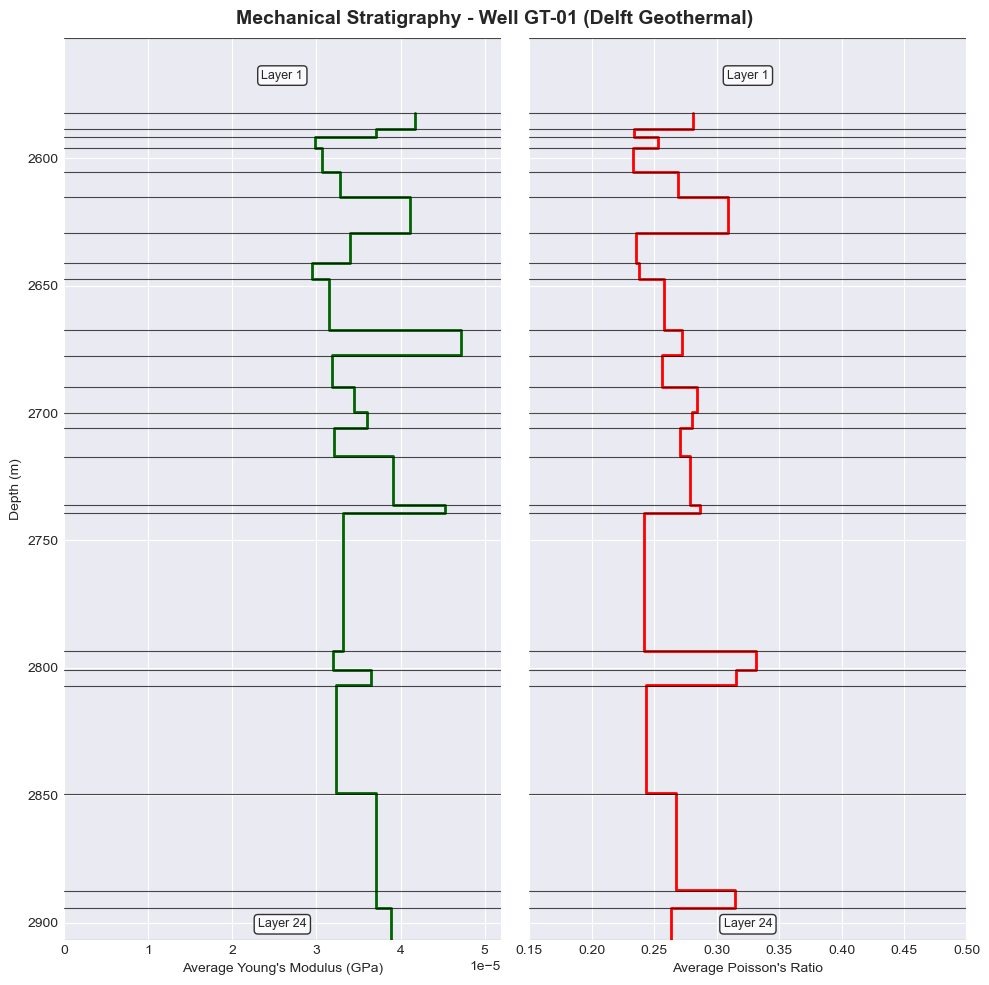

In [300]:

fig, axes = plt.subplots(1, 2, figsize=(10, 10), sharey=True)
fig.suptitle('Mechanical Stratigraphy - Well GT-01 (Delft Geothermal)', fontsize=14, fontweight='bold')


# Panel (a): Average Young's Modulus per layer - Step plot
x_max_e = layer_stats['E_avg'].max() * 1.1
depths = []
values_e = []
for idx, row in layer_stats.iterrows():
    if idx == 0:  # Skip layer 1 for plotting
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_e.extend([None, None])
    else:
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_e.extend([row['E_avg'], row['E_avg']])

axes[0].plot(values_e, depths, color='darkgreen', linewidth=2, drawstyle='steps-post')


# Add horizontal gridlines at layer boundaries
for idx, row in layer_stats.iterrows():
    axes[0].axhline(y=row['Depth_min'], color='black', linewidth=0.8, alpha=0.7)
axes[0].axhline(y=layer_stats.iloc[-1]['Depth_max'], color='black', linewidth=0.8, alpha=0.7)
axes[0].set_xlabel('Average Young\'s Modulus (GPa)')
axes[0].set_ylabel('Depth (m)')
axes[0].invert_yaxis()
axes[0].set_xlim(0, x_max_e)
axes[0].set_ylim(layer_stats.iloc[-1]['Depth_max'], layer_stats.iloc[0]['Depth_min'])
# Add Layer text
axes[0].text(x_max_e * 0.5, layer_stats.iloc[0]['Depth_mid'], 'Layer 1', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0].text(x_max_e * 0.5, layer_stats.iloc[-1]['Depth_mid'], f'Layer {len(layer_stats)}', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# Panel (b): Average Poisson's Ratio per layer - Step plot
depths = []
values_nu = []
for idx, row in layer_stats.iterrows():
    if idx == 0:  # Skip layer 1 for plotting
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_nu.extend([None, None])
    else:
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_nu.extend([row['nu_avg'], row['nu_avg']])

axes[1].plot(values_nu, depths, color='red', linewidth=2, drawstyle='steps-post')


# Add horizontal gridlines at layer boundaries
for idx, row in layer_stats.iterrows():
    axes[1].axhline(y=row['Depth_min'], color='black', linewidth=0.8, alpha=0.7)
axes[1].axhline(y=layer_stats.iloc[-1]['Depth_max'], color='black', linewidth=0.8, alpha=0.7)
axes[1].set_xlabel('Average Poisson\'s Ratio')
axes[1].set_xlim(0.15, 0.5)


# Add Layer text
axes[1].text(0.325, layer_stats.iloc[0]['Depth_mid'], 'Layer 1', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[1].text(0.325, layer_stats.iloc[-1]['Depth_mid'], f'Layer {len(layer_stats)}', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()

#### **8. Property Ratio Analysis Between Adjacent Layers**

After step 7 completed, then we calculated the ratios by dividing the elastic property of layer (i) over the elastic property of the layer above (i-1) = ( $E_i$/$E_{i-1}$ and $ν_i$ / $ν_{i-1}$) to quantify mechanical contrast.

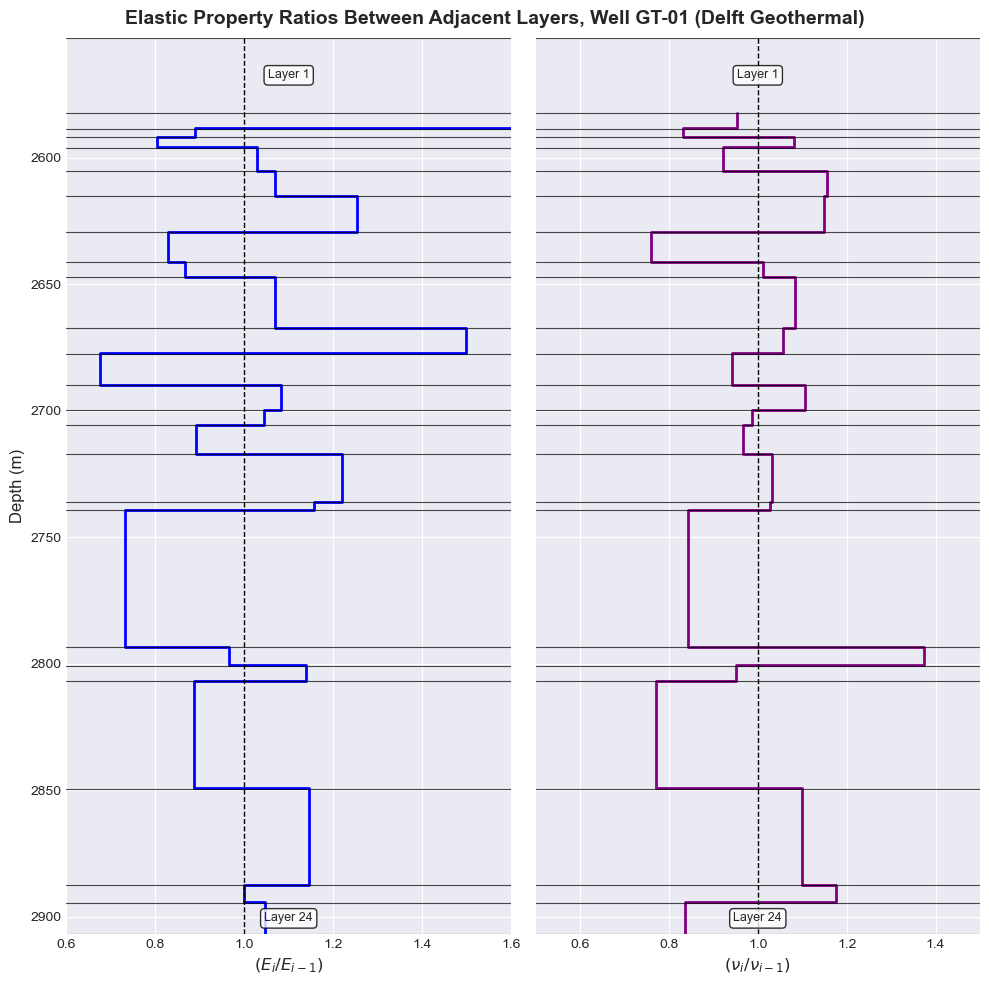

In [301]:
# Calculating property ratios between consecutive layers
layer_stats['E_ratio'] = layer_stats['E_avg'] / layer_stats['E_avg'].shift(1)
layer_stats['nu_ratio'] = layer_stats['nu_avg'] / layer_stats['nu_avg'].shift(1)


# Visualizing
fig, axes = plt.subplots(1, 2, figsize=(10, 10), sharey=True)
fig.suptitle('Elastic Property Ratios Between Adjacent Layers, Well GT-01 (Delft Geothermal)', fontsize=14, fontweight='bold')


# Panel (a): Young's Modulus Ratio (E_i/E_{i-1}) - Step plot
depths = []
values_e_ratio = []
for idx, row in layer_stats.iterrows():
    if idx == 0:  # Layer 1 has no ratio
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_e_ratio.extend([None, None])
    elif not pd.isna(row['E_ratio']):
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_e_ratio.extend([row['E_ratio'], row['E_ratio']])

axes[0].plot(values_e_ratio, depths, color='blue', linewidth=2, drawstyle='steps-post')
axes[0].axvline(x=1.0, color='black', linestyle='--', linewidth=1)


# Add horizontal gridlines at layer boundaries
for idx, row in layer_stats.iterrows():
    axes[0].axhline(y=row['Depth_min'], color='black', linewidth=0.8, alpha=0.7)
axes[0].axhline(y=layer_stats.iloc[-1]['Depth_max'], color='black', linewidth=0.8, alpha=0.7)
axes[0].set_xlabel('$(E_i/E_{i-1})$', fontsize=12)
axes[0].set_ylabel('Depth (m)', fontsize=12)
axes[0].invert_yaxis()
axes[0].set_xlim(0.6, 1.6)
axes[0].set_ylim(layer_stats.iloc[-1]['Depth_max'], layer_stats.iloc[0]['Depth_min'])
# Add Layer text
axes[0].text(1.1, layer_stats.iloc[0]['Depth_mid'], 'Layer 1', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0].text(1.1, layer_stats.iloc[-1]['Depth_mid'], f'Layer {len(layer_stats)}', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# Panel (b): Poisson's Ratio (ν_i/ν_{i-1}) - Step plot
depths = []
values_nu_ratio = []
for idx, row in layer_stats.iterrows():
    if idx == 0:  # Layer 1 has no ratio
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_nu_ratio.extend([None, None])
    elif not pd.isna(row['nu_ratio']):
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_nu_ratio.extend([row['nu_ratio'], row['nu_ratio']])

axes[1].plot(values_nu_ratio, depths, color='purple', linewidth=2, drawstyle='steps-post')
axes[1].axvline(x=1.0, color='black', linestyle='--', linewidth=1)


# Add horizontal gridlines at layer boundaries
for idx, row in layer_stats.iterrows():
    axes[1].axhline(y=row['Depth_min'], color='black', linewidth=0.8, alpha=0.7)
axes[1].axhline(y=layer_stats.iloc[-1]['Depth_max'], color='black', linewidth=0.8, alpha=0.7)
axes[1].set_xlabel(r'$(\nu_i/\nu_{i-1})$', fontsize=12)


axes[1].set_xlim(0.5, 1.5)
# Add Layer text
axes[1].text(1.0, layer_stats.iloc[0]['Depth_mid'], 'Layer 1', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[1].text(1.0, layer_stats.iloc[-1]['Depth_mid'], f'Layer {len(layer_stats)}', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


#### **9. Predicted Horizontal Stress and Fracture Behaviour**

Following the methodology from Boersma et al. (2020), we predict the horizontal stress and fracture behaviour for each layer based on the contrast in elastic properties. The prediction is done by placing the average ratios in elastic properties (from the previous analysis) into the stress model.

The normalized horizontal stress parameter is calculated as:
$$ \frac{\sigma_h}{\sigma_{applied}} = (E_{ratio} - 1.0) \times (\nu_{avg} - 0.25) \times 2.0 $$

Based on this stress value, layers are classified into different fracture modes:
- **Mode I Tensile**: σ < -0.075 (layers expected to fracture in tension)
- **Hybrid [Tensile]**: -0.075 ≤ σ < 0.0 (transitional with tensile dominance)
- **Hybrid [Shear]**: 0.0 ≤ σ < 0.075 (transitional with shear dominance)
- **Mode II Compressive**: σ ≥ 0.075 (layers expected to fracture in compression)

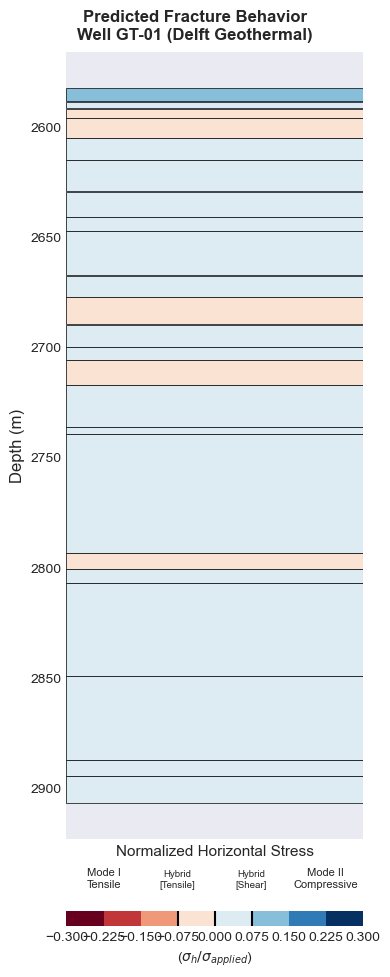

Fracture_Mode
Hybrid [Shear]         17
Hybrid [Tensile]        5
Mode II Compressive     1
Unknown                 1
Name: count, dtype: int64

Layers by Fracture Mode:
  Hybrid [Tensile]: 5 layers
  Hybrid [Shear]: 17 layers
  Mode II Compressive: 1 layers


In [303]:
# Calculating normalized horizontal stress parameter
layer_stats['Stress_norm'] = (layer_stats['E_ratio'] - 1.0) * (layer_stats['nu_avg'] - 0.25) * 2.0

# Function to classify fracture mode based on stress
def classify_fracture_mode(stress):
    if pd.isna(stress):
        return 'Unknown'
    elif stress < -0.075:
        return 'Mode I Tensile'
    elif -0.075 <= stress < 0:
        return 'Hybrid [Tensile]'
    elif 0 <= stress < 0.075:
        return 'Hybrid [Shear]'
    else:
        return 'Mode II Compressive'

layer_stats['Fracture_Mode'] = layer_stats['Stress_norm'].apply(classify_fracture_mode)

# Visualizing normalized horizontal stress with discrete colormap
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable

fig, ax = plt.subplots(1, 1, figsize=(4, 10))
fig.suptitle('Predicted Fracture Behavior\nWell GT-01 (Delft Geothermal)', fontsize=12, fontweight='bold')

# Discrete colormap with 8 segments
boundaries = [-0.3, -0.225, -0.15, -0.075, 0.0, 0.075, 0.15, 0.225, 0.3]
norm = BoundaryNorm(boundaries, ncolors=256)
cmap = plt.cm.RdBu  # Red (tensile/negative) to Blue (compressive/positive)

for idx, row in layer_stats.iterrows():
    if not pd.isna(row['Stress_norm']):
        color = cmap(norm(row['Stress_norm']))
        ax.barh(row['Depth_mid'], 1, height=row['Thickness'], 
                color=color, edgecolor='black', linewidth=0.5)

ax.set_ylabel('Depth (m)', fontsize=12)
ax.set_xlabel('Normalized Horizontal Stress', fontsize=11)
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.invert_yaxis()
ax.grid(False)

# Adding colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.08, fraction=0.05, aspect=20)
cbar.set_label(r'($\sigma_h/\sigma_{applied}$)', fontsize=10)

# Adding fracture mode labels above colorbar
y_label_pos = 2.5
cbar.ax.text(0.125, y_label_pos, 'Mode I\nTensile', ha='center', va='bottom', fontsize=8, 
             transform=cbar.ax.transAxes, fontweight='normal')
cbar.ax.text(0.375, y_label_pos, 'Hybrid\n[Tensile]', ha='center', va='bottom', fontsize=7, 
             transform=cbar.ax.transAxes)
cbar.ax.text(0.625, y_label_pos, 'Hybrid\n[Shear]', ha='center', va='bottom', fontsize=7, 
             transform=cbar.ax.transAxes)
cbar.ax.text(0.875, y_label_pos, 'Mode II\nCompressive', ha='center', va='bottom', fontsize=8, 
             transform=cbar.ax.transAxes, fontweight='normal')

# Adding vertical separator lines at fracture mode boundaries
boundary_values = [-0.075, 0.0, 0.075]
for boundary in boundary_values:
    cbar.ax.axvline(x=boundary, color='black', linewidth=1.5, linestyle='-')

plt.tight_layout()
plt.show()

# Summary statistics
print(layer_stats['Fracture_Mode'].value_counts())
print(f"\nLayers by Fracture Mode:")
for mode in ['Mode I Tensile', 'Hybrid [Tensile]', 'Hybrid [Shear]', 'Mode II Compressive']:
    count = (layer_stats['Fracture_Mode'] == mode).sum()
    if count > 0:
        print(f"  {mode}: {count} layers")

#### **10. Comprehensive Mechanical Stratigraphy (Combined Logs)**

This combined visualization shows all mechanical properties and fracture predictions in a single comprehensive figure, similar to Figure 9 from Boersma et al. (2020).

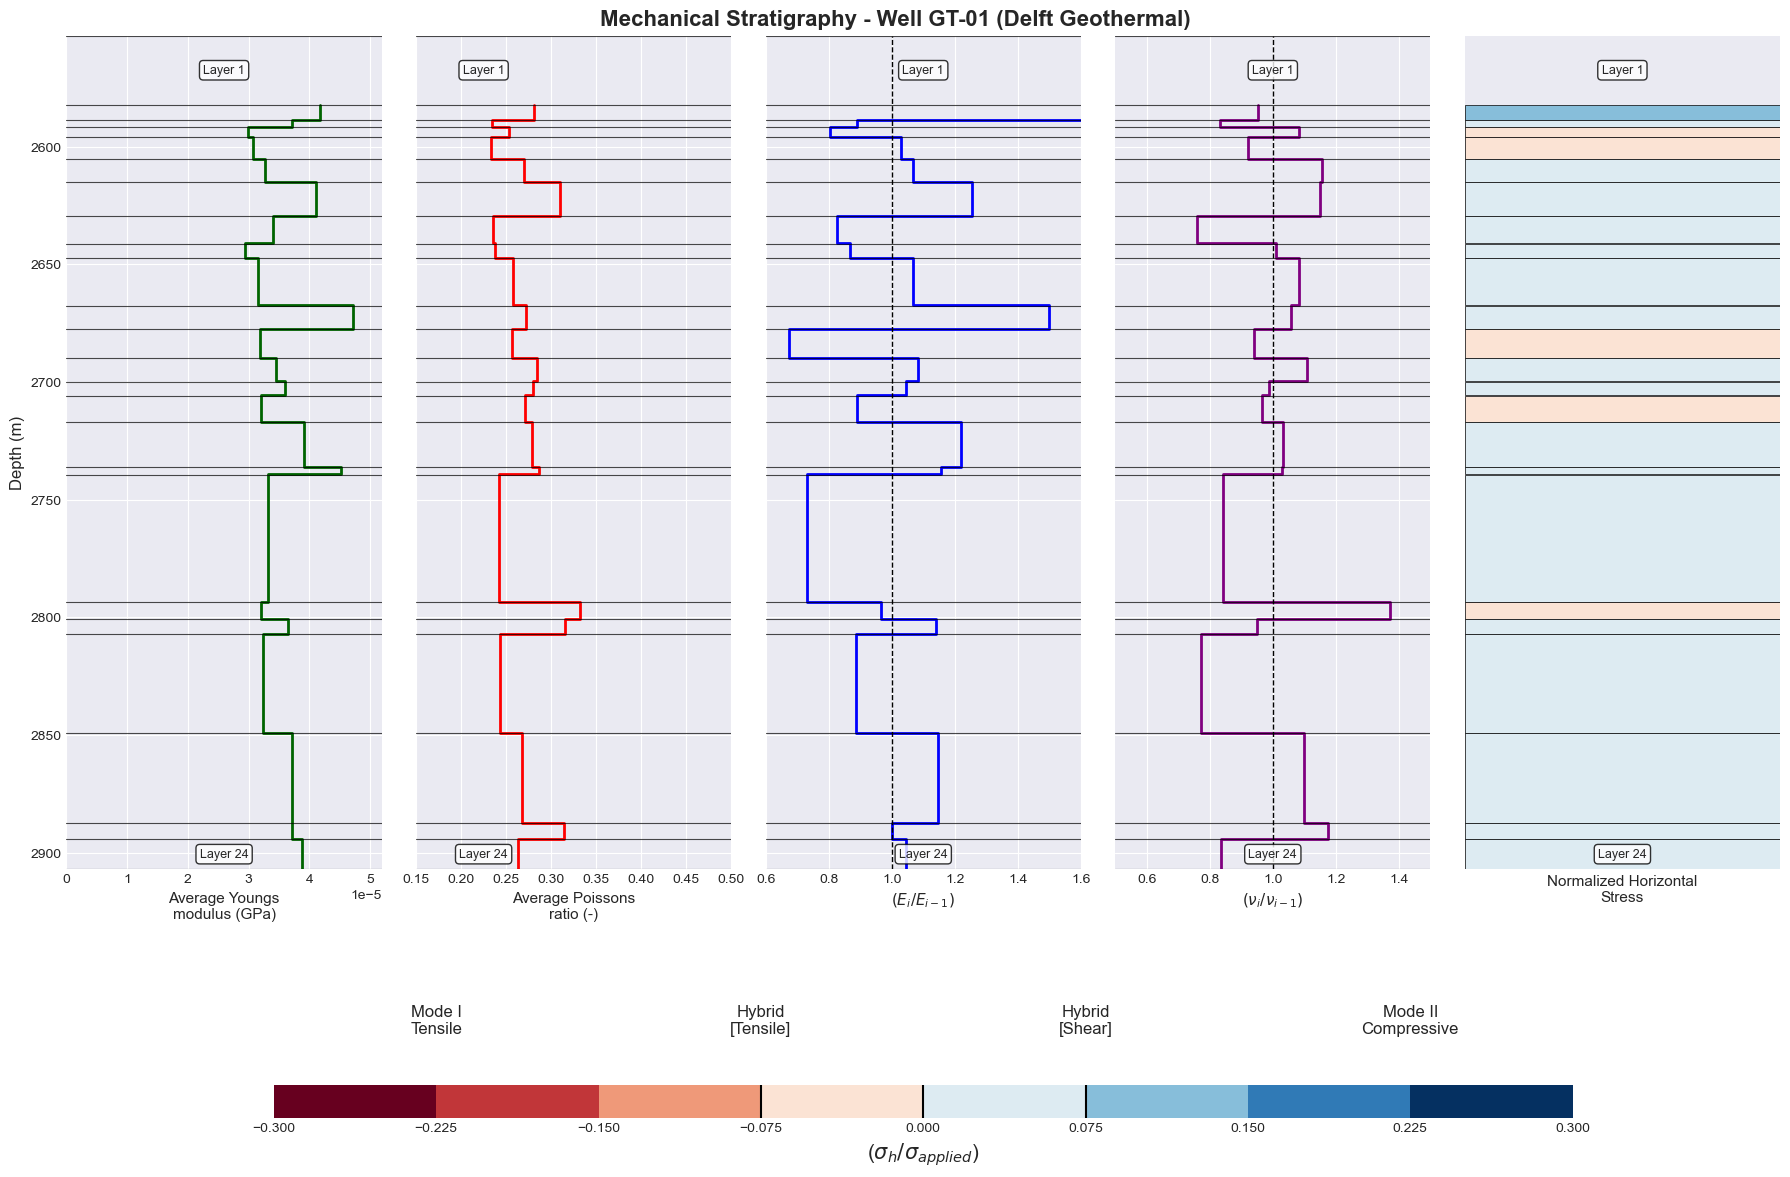

In [304]:
from matplotlib.colors import BoundaryNorm
from matplotlib.cm import ScalarMappable
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 5, figsize=(18, 12), sharey=True)
fig.suptitle('Mechanical Stratigraphy - Well GT-01 (Delft Geothermal)', 
             fontsize=16, fontweight='bold')

# Defining colors for each panel
colors = ['darkgreen', 'red', 'blue', 'purple']



# Panel (a): Average Young's Modulus - Step plot
x_max_e = layer_stats['E_avg'].max() * 1.1
depths = []
values_e = []
for idx, row in layer_stats.iterrows():
    if idx == 0:  # Skip layer 1 for plotting
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_e.extend([None, None])
    else:
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_e.extend([row['E_avg'], row['E_avg']])



# Plot step function
axes[0].plot(values_e, depths, color=colors[0], linewidth=2, drawstyle='steps-post')
# Add horizontal gridlines at layer boundaries
for idx, row in layer_stats.iterrows():
    axes[0].axhline(y=row['Depth_min'], color='black', linewidth=0.8, alpha=0.7)
axes[0].axhline(y=layer_stats.iloc[-1]['Depth_max'], color='black', linewidth=0.8, alpha=0.7)
axes[0].set_xlabel('Average Youngs\nmodulus (GPa)', fontsize=11)
axes[0].set_ylabel('Depth (m)', fontsize=12)
axes[0].invert_yaxis()
axes[0].set_xlim(0, x_max_e)
axes[0].set_ylim(layer_stats.iloc[-1]['Depth_max'], layer_stats.iloc[0]['Depth_min'])
# Add Layer text
axes[0].text(x_max_e * 0.5, layer_stats.iloc[0]['Depth_mid'], 'Layer 1', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[0].text(x_max_e * 0.5, layer_stats.iloc[-1]['Depth_mid'], f'Layer {len(layer_stats)}', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))



# Panel (b): Average Poisson's Ratio - Step plot
depths = []
values_nu = []
for idx, row in layer_stats.iterrows():
    if idx == 0:  # Skip layer 1 for plotting
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_nu.extend([None, None])
    else:
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_nu.extend([row['nu_avg'], row['nu_avg']])

axes[1].plot(values_nu, depths, color=colors[1], linewidth=2, drawstyle='steps-post')


# Add horizontal gridlines at layer boundaries
for idx, row in layer_stats.iterrows():
    axes[1].axhline(y=row['Depth_min'], color='black', linewidth=0.8, alpha=0.7)
axes[1].axhline(y=layer_stats.iloc[-1]['Depth_max'], color='black', linewidth=0.8, alpha=0.7)
axes[1].set_xlabel('Average Poissons\nratio (-)', fontsize=11)
axes[1].set_xlim(0.15, 0.5)


# Add Layer text
axes[1].text(0.225, layer_stats.iloc[0]['Depth_mid'], 'Layer 1', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[1].text(0.225, layer_stats.iloc[-1]['Depth_mid'], f'Layer {len(layer_stats)}', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# Panel (c): Young's Modulus Ratio (E_i/E_{i-1}) - Step plot
depths = []
values_e_ratio = []
for idx, row in layer_stats.iterrows():
    if idx == 0:  # Layer 1 has no ratio
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_e_ratio.extend([None, None])
    elif not pd.isna(row['E_ratio']):
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_e_ratio.extend([row['E_ratio'], row['E_ratio']])

axes[2].plot(values_e_ratio, depths, color=colors[2], linewidth=2, drawstyle='steps-post')
axes[2].axvline(x=1.0, color='black', linestyle='--', linewidth=1)


# Add horizontal gridlines at layer boundaries
for idx, row in layer_stats.iterrows():
    axes[2].axhline(y=row['Depth_min'], color='black', linewidth=0.8, alpha=0.7)
axes[2].axhline(y=layer_stats.iloc[-1]['Depth_max'], color='black', linewidth=0.8, alpha=0.7)
axes[2].set_xlabel(r'$(E_i/E_{i-1})$', fontsize=11)
axes[2].set_xlim(0.6, 1.6)
# Add Layer text
axes[2].text(1.1, layer_stats.iloc[0]['Depth_mid'], 'Layer 1', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[2].text(1.1, layer_stats.iloc[-1]['Depth_mid'], f'Layer {len(layer_stats)}', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# Panel (d): Poisson's Ratio (ν_i/ν_{i-1}) - Step plot
depths = []
values_nu_ratio = []
for idx, row in layer_stats.iterrows():
    if idx == 0:  # Layer 1 has no ratio
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_nu_ratio.extend([None, None])
    elif not pd.isna(row['nu_ratio']):
        depths.extend([row['Depth_min'], row['Depth_max']])
        values_nu_ratio.extend([row['nu_ratio'], row['nu_ratio']])

axes[3].plot(values_nu_ratio, depths, color=colors[3], linewidth=2, drawstyle='steps-post')
axes[3].axvline(x=1.0, color='black', linestyle='--', linewidth=1)


# Add horizontal gridlines at layer boundaries
for idx, row in layer_stats.iterrows():
    axes[3].axhline(y=row['Depth_min'], color='black', linewidth=0.8, alpha=0.7)
axes[3].axhline(y=layer_stats.iloc[-1]['Depth_max'], color='black', linewidth=0.8, alpha=0.7)
axes[3].set_xlabel(r'$(\nu_i/\nu_{i-1})$', fontsize=11)
axes[3].set_xlim(0.5, 1.5)
# Add Layer text
axes[3].text(1.0, layer_stats.iloc[0]['Depth_mid'], 'Layer 1', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[3].text(1.0, layer_stats.iloc[-1]['Depth_mid'], f'Layer {len(layer_stats)}', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# Panel (e): Normalized Horizontal Stress with discrete colormap
boundaries = [-0.3, -0.225, -0.15, -0.075, 0.0, 0.075, 0.15, 0.225, 0.3]
norm = BoundaryNorm(boundaries, ncolors=256)
cmap = plt.cm.RdBu  # Red (tensile/negative) to Blue (compressive/positive)

for idx, row in layer_stats.iterrows():
    if not pd.isna(row['Stress_norm']):
        color = cmap(norm(row['Stress_norm']))
        axes[4].barh(row['Depth_mid'], 1, height=row['Thickness'], 
                     color=color, edgecolor='black', linewidth=0.5)

axes[4].set_xlabel('Normalized Horizontal\nStress', fontsize=11)
axes[4].set_xlim(0, 1)
axes[4].set_xticks([])
axes[4].grid(False)


# Add Layer text
axes[4].text(0.5, layer_stats.iloc[0]['Depth_mid'], 'Layer 1', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
axes[4].text(0.5, layer_stats.iloc[-1]['Depth_mid'], f'Layer {len(layer_stats)}', 
             ha='center', va='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()


# Adding colorbar below all panels
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation='horizontal', pad=0.2, fraction=0.03, aspect=40)
cbar.set_label(r'($\sigma_h/\sigma_{applied}$)', fontsize=15)

# Adding fracture mode labels above colorbar
y_label_pos = 2.5
cbar.ax.text(0.125, y_label_pos, 'Mode I\nTensile', ha='center', va='bottom', fontsize=12, 
             transform=cbar.ax.transAxes, fontweight='normal')
cbar.ax.text(0.375, y_label_pos, 'Hybrid\n[Tensile]', ha='center', va='bottom', fontsize=12, 
             transform=cbar.ax.transAxes)
cbar.ax.text(0.625, y_label_pos, 'Hybrid\n[Shear]', ha='center', va='bottom', fontsize=12, 
             transform=cbar.ax.transAxes)
cbar.ax.text(0.875, y_label_pos, 'Mode II\nCompressive', ha='center', va='bottom', fontsize=12, 
             transform=cbar.ax.transAxes, fontweight='normal')


# Adding vertical separator lines at fracture mode boundaries
boundary_values = [-0.075, 0.0, 0.075]
for boundary in boundary_values:
    cbar.ax.axvline(x=boundary, color='black', linewidth=1.5, linestyle='-')

plt.show()